# 高校数学とPython Day 3【Python版】

- 城北中学校・高等学校　中学3年・高校1年
- 夏期講習会III 2026/8/24~2026/8/28
- 担当:清水団

## 本日のテーマ:場合の数・組合せを実験しよう!

Julia版と同じ内容を **Python** で体験するバージョンです。言語ごとの書き方の違いにも注目してみてください。

### 5日間の学習予定

- **Day 1**:基本計算・for文・if文 ✅
- **Day 2**:整数問題をプログラムで考えよう ✅
- **Day 3**:場合の数・組合せを実験しよう ← 今日
- **Day 4**:関数・グラフ・最大最小
- **Day 5**:確率・シミュレーション


## 樹形図の代わりに全部生成

**itertools** モジュールが場合の数の主役です。

In [1]:
# 3重forでもOK
for a in [1, 2, 3]:
    for b in [1, 2, 3]:
        for c in [1, 2, 3]:
            print(f"{a}{b}{c}")

111
112
113
121
122
123
131
132
133
211
212
213
221
222
223
231
232
233
311
312
313
321
322
323
331
332
333


In [2]:
# itertools.product ならもっとスマート
from itertools import product, permutations, combinations

for a, b, c in product([1, 2, 3], repeat=3):
    print(f"{a}{b}{c}")

111
112
113
121
122
123
131
132
133
211
212
213
221
222
223
231
232
233
311
312
313
321
322
323
331
332
333


In [3]:
# 何通り?
len(list(product([1, 2, 3], repeat=3)))  # 3^3 = 27

27

In [4]:
# コイン3回の表裏
for p in product("表裏", repeat=3):
    print("".join(p))

表表表
表表裏
表裏表
表裏裏
裏表表
裏表裏
裏裏表
裏裏裏


## 順列(permutations):5人から3人選んで並べる

In [5]:
people = ["A", "B", "C", "D", "E"]
for p in permutations(people, 3):
    print("".join(p))

ABC
ABD
ABE
ACB
ACD
ACE
ADB
ADC
ADE
AEB
AEC
AED
BAC
BAD
BAE
BCA
BCD
BCE
BDA
BDC
BDE
BEA
BEC
BED
CAB
CAD
CAE
CBA
CBD
CBE
CDA
CDB
CDE
CEA
CEB
CED
DAB
DAC
DAE
DBA
DBC
DBE
DCA
DCB
DCE
DEA
DEB
DEC
EAB
EAC
EAD
EBA
EBC
EBD
ECA
ECB
ECD
EDA
EDB
EDC


In [6]:
import math
len(list(permutations(people, 3))), 5*4*3  # ₅P₃ = 60

(60, 60)

In [7]:
math.factorial(5), len(list(permutations(people)))  # 全員並べると5!

(120, 120)

## 組合せ(combinations):選ぶだけなら?

In [8]:
for c in combinations(people, 3):
    print("".join(c))

ABC
ABD
ABE
ACD
ACE
ADE
BCD
BCE
BDE
CDE


In [9]:
len(list(combinations(people, 3))), math.comb(5, 3)  # ₅C₃ = 10

(10, 10)

In [10]:
# PとCの関係:60 ÷ 3! = 10
len(list(permutations(people, 3))) // math.factorial(3) == math.comb(5, 3)

True

## 重複順列・円順列

In [11]:
# ○×クイズ5問:2^5 = 32通り
len(list(product(["○", "×"], repeat=5))), 2**5

(32, 32)

In [12]:
# 円順列:Aを固定して残り4人を並べる → (5-1)!
for p in permutations(["B", "C", "D", "E"]):
    print("A-" + "-".join(p))
print(math.factorial(4), "通り")

A-B-C-D-E
A-B-C-E-D
A-B-D-C-E
A-B-D-E-C
A-B-E-C-D
A-B-E-D-C
A-C-B-D-E
A-C-B-E-D
A-C-D-B-E
A-C-D-E-B
A-C-E-B-D
A-C-E-D-B
A-D-B-C-E
A-D-B-E-C
A-D-C-B-E
A-D-C-E-B
A-D-E-B-C
A-D-E-C-B
A-E-B-C-D
A-E-B-D-C
A-E-C-B-D
A-E-C-D-B
A-E-D-B-C
A-E-D-C-B
24 通り


## 同じものを含む順列

In [13]:
# set で重複を取り除く
narabe = set(permutations("AABBB"))
for p in sorted(narabe):
    print("".join(p))
print(len(narabe), "通り")

AABBB
ABABB
ABBAB
ABBBA
BAABB
BABAB
BABBA
BBAAB
BBABA
BBBAA
10 通り


In [14]:
# 公式 5!/(2!3!) と比較
math.factorial(5) // (math.factorial(2) * math.factorial(3))

10

## パスカルの三角形

In [15]:
for n in range(11):
    row = [math.comb(n, r) for r in range(n + 1)]
    print(" " * (2*(10 - n)), " ".join(f"{v:3d}" for v in row))

                       1
                     1   1
                   1   2   1
                 1   3   3   1
               1   4   6   4   1
             1   5  10  10   5   1
           1   6  15  20  15   6   1
         1   7  21  35  35  21   7   1
       1   8  28  56  70  56  28   8   1
     1   9  36  84 126 126  84  36   9   1
   1  10  45 120 210 252 210 120  45  10   1


In [16]:
# 各行の和は2^n になっている!
for n in range(11):
    print(f"n={n}: 和 = {sum(math.comb(n, r) for r in range(n + 1))}")

n=0: 和 = 1
n=1: 和 = 2
n=2: 和 = 4
n=3: 和 = 8
n=4: 和 = 16
n=5: 和 = 32
n=6: 和 = 64
n=7: 和 = 128
n=8: 和 = 256
n=9: 和 = 512
n=10: 和 = 1024


## 二項係数に色を塗ると…(シェルピンスキーのガスケット)

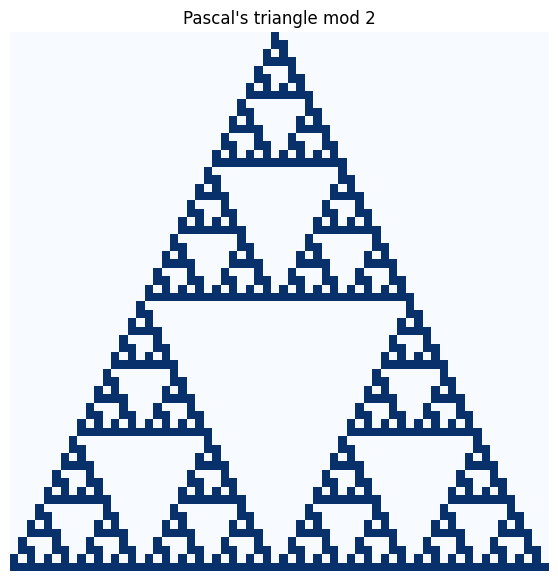

In [17]:
import matplotlib.pyplot as plt
import numpy as np

N = 64
grid = np.zeros((N, N))
for n in range(N):
    for r in range(n + 1):
        grid[n, r + (N - 1 - n)//2] = math.comb(n, r) % 2

plt.figure(figsize=(7, 7))
plt.imshow(grid, cmap="Blues")
plt.axis("off")
plt.title("Pascal's triangle mod 2")
plt.show()

## Day 3 の演習問題

### 問題1: 6人から2人選ぶ方法を全部表示 → math.comb(6,2) と比較
### 問題2: 「JOHOKU」の並べ替えは何通り?(set(permutations(...)) と 6!/2! で)
### 問題3: サイコロ2個で和が7になる場合を全部表示
### 問題4: パスカルの三角形の各行の奇数の個数(n=0〜16)の規則を予想

## 解答欄

In [18]:
# 問題1



In [19]:
# 問題2



In [20]:
# 問題3



In [21]:
# 問題4



## Day 3 まとめ

- itertoolsの product・permutations・combinations が三種の神器
- 個数の公式は math.comb・math.factorial で確認
- 「全部作ってから公式へ」の流れはJulia版と同じ!